### An Invitation to Analytic Combinatorics - Lecture 3

This SageMath notebook works contains the Sage code presented in Lecture 2 of the MPI Lecture Series presented by Stephen Melczer in June 2026.

### Part 1: Basics of Analytic Combinatorics

In [1]:
# The principal branch of F(z) = sqrt(z) is defined 
# by the ODE 2zF'(z) - F(z) = 0 and F(1)=1

# Import the ore_algebra package
# THIS REQUIRES THE ore_algebra PACKAGE 
# FROM https://github.com/mkauers/ore_algebra
from ore_algebra import *
Pols.<z> = QQ['z']
Diff.<Dz> = OreAlgebra(Pols)
  
# Define the ODE 2zF'(z) - F(z) = 0
deq = 2*z*Dz - 1

# Continue solution with F(1)=1 to z=-1 ABOVE real axis
deq.numerical_solution(ini=[1], path=[1, I, -1])

[+/- 6.68e-21] + [1.0000000000000000 +/- 6.11e-20]*I

In [2]:
# Continue solution with F(1)=1 to z=-1 BELOW real axis
deq.numerical_solution(ini=[1], path=[1, -I, -1])

[+/- 6.68e-21] + [-1.0000000000000000 +/- 6.11e-20]*I

### Part 2: Transfer Theorems

In [3]:
# Residue of tangent at pi/2
var('z')
tan(z).series(z==pi/2, 1)

(-1)*(-1/2*pi + z)^(-1) + Order(-1/2*pi + z)

In [4]:
# Asymptotics of Surjections
var('n z')
G = 1
H = 2-exp(z)
(1/log(2))^n * (-G/diff(H,z)/z).subs(z=log(2))

1/2*log(2)^(-n)/log(2)

In [5]:
# Catalan asymptotics using AsymptoticRing
A.<n> = AsymptoticRing('n^QQ * QQ^n', coefficient_ring=SR)
def C(z): return (1-sqrt(1-4*z))/(2*z)
  
show(A.coefficients_of_generating_function(function=C,
                                           singularities=(1/4),
                                           precision=4))

1/sqrt(pi)*n^(-3/2)*4^n - 9/8/sqrt(pi)*n^(-5/2)*4^n + 145/128/sqrt(pi)*n^(-7/2)*4^n - 1155/1024/sqrt(pi)*n^(-9/2)*4^n + O(n^(-5)*4^n)

### Part 3: Algebraic Functions

In [6]:
# Equation defining Catalan number GF
var('z y')
P = z*y^2 - y + 1
P.resultant(P.diff(y),y)

4*z^2 - z

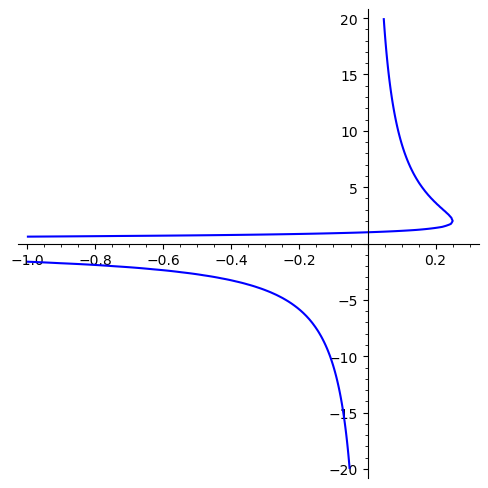

In [7]:
# Plot algebraic curve defined by P = 0 
# Note: plot with black background for slides is below
equation = P == 0
p = implicit_plot(equation, (z, -1, 0.3), (y, -20, 20), frame=False, axes=True)
p.show(figsize=[5, 5], aspect_ratio='automatic')

In [8]:
# Asymptotics of Central Binomial Coefficients
def F(z): return (1-4*z)^(-1/2)
show(A.coefficients_of_generating_function(function=F,
                                           singularities=(1/4),
                                           precision=4))

1/sqrt(pi)*n^(-1/2)*4^n - 1/8/sqrt(pi)*n^(-3/2)*4^n + 1/128/sqrt(pi)*n^(-5/2)*4^n + 5/1024/sqrt(pi)*n^(-7/2)*4^n + O(n^(-9/2)*4^n)

In [9]:
# Asymptotics of Labelled 2-Regular Graphs
def G(z): return exp(-z/2-z^2/4)/sqrt(1-z)
show(A.coefficients_of_generating_function(function=G,
                                           singularities=(QQ(1)),
                                           precision=3))

(e^(-3/4)/sqrt(pi))*n^(-1/2) + (-5/8*e^(-3/4)/sqrt(pi))*n^(-3/2) + (1/128*e^(-3/4)/sqrt(pi))*n^(-5/2) + O(n^(-7/2))

In [10]:
# The following code computes Puiseux series expansions around the origin
# NOTE: This code is still in development and needs more testing.
#       It also does not use Newton iteration for fast series development after branch separation.
#       *** When complete it will be available in the sage_acsv package. *** 
from sage.geometry.newton_polygon import NewtonPolygon

# Wrapper that calls main function below and converts output to list of Puiseux series
def compute_Puiseux_solutions(P, x_var, y_var, N, fractional_power_series=False):
    # Error checking
    if set(P.variables()) != {x_var, y_var}: raise ValueError("Only variables in P should be the variables given in the arguments.")
    
    # Compute each Puiseux series solution as a dictionary of coefficients and exponents
    dictionary_branches = _compute_Puiseux_solutions(P, x_var, y_var, N, fractional_power_series)

    # Build the Puiseux series ring
    P = PuiseuxSeriesRing(QQbar, str(x_var))
    x_P = P.gen()
    expansions = []

    # Convert each dictionary into an element of the Puiseux series ring
    for branch in dictionary_branches:
        expr = P.zero()
        for coeff, exp in branch:
            if coeff == "O":
                expr += O(x_P^exp)
            else:
                expr += coeff * x_P^exp
        expansions.append(expr)
        
    return expansions

# Compute terms in the Puiseux series solutions y(x) to P(x,y) = 0
def _compute_Puiseux_solutions(P, x_var, y_var, N, fractional_power_series=False):
    # Build polynomial rings and variables to be used below
    Rx = PolynomialRing(QQbar, str(x_var))
    x_gen = Rx.gen()
    Rxy = PolynomialRing(Rx, str(y_var))
    y_gen = Rxy.gen()

    # Express input polynomial as a polynomial in \overline{Q}[x][y] 
    pol = Rxy(P)
    if pol == 0: return []

    # Compute valuations of coefficients
    vals = {i: pol[i].valuation() for i in range(pol.degree() + 1) if pol[i] != 0}
    if not vals: return []
    
    # Build Newton polygon of P and extract negated slopes 
    pts = [(i, v) for i, v in vals.items()]
    negated_slopes = sorted({-QQ(s) for s in NewtonPolygon(pts).slopes()})
    if fractional_power_series:
        negated_slopes = [a for a in negated_slopes if a >= 0]

    # Iterate through each negated slope
    sols = []
    for alpha in negated_slopes:
        r, num = alpha.denominator(), alpha.numerator()
        
        # Find the lowest coefficient valuation m
        m = min(v * r + num * i for i, v in vals.items())
        
        # Build the characteristic polynomial using only terms on the Newton polygon edge (where v * r + num * i == m)
        char_poly_dict = {i: pol[i][v] for i, v in vals.items() if v * r + num * i == m}
        v_min = min(char_poly_dict.keys())
        Ry = PolynomialRing(QQbar, str(y_var))
        char_poly = Ry({i - v_min: c for i, c in char_poly_dict.items()})
        if char_poly == 0: continue

        # Build transformed polynomial p after mapping x^k -> x^(k*r + num*i - m)
        p_dict = {}
        for i in vals:
            new_x_poly_dict = {k * r + num * i - m: c for k, c in pol[i].dict().items()}
            p_dict[i] = Rx(new_x_poly_dict)
        p = Rxy(p_dict)

        for lc, mult in char_poly.roots():
            # Simple root case -- find remaining terms iteratively
            if mult == 1:
                current_sol = [(lc, alpha)]
                p2 = p(y_gen + lc)
                c1 = p2[1][0]
                if c1 == 0: raise ValueError("Simple root was somehow singular")
                
                y_accum = Rx(0) 
                for step in range(1, N + 1):
                    c0 = p2(y_accum)[step]
                    ai = -c0 / c1
                    if ai in QQ: ai = QQ(ai)
                    current_sol.append((ai, alpha + step/r))
                    y_accum += ai * (x_gen**step)
                
                current_sol.append(("O", alpha + (N + 1)/r))
                sols.append(current_sol)
                
            # Multiple root case -- need to recurse
            else:
                if N <= 0:
                    for _ in range(mult): sols.append([("O", alpha)])
                    continue
                
                # Shift and scale for the next level of recursion
                p_shift = p(y_gen + lc)
                p_final_dict = {}
                for i in range(p_shift.degree() + 1):
                    if p_shift[i] != 0:
                        p_final_dict[i] = Rx({int(k * mult + i): c for k, c in p_shift[i].dict().items()})
                
                # Further shift y -> x*y to resolve singularity
                p_final = Rxy(p_final_dict)

                # Final argument is True since we already have first terms of solution
                sub_branches = _compute_Puiseux_solutions(p_final, x_var, y_var, N - 1, True)
                for branch in sub_branches:
                    adj = [(lc, alpha)]
                    for val, exp in branch:
                        if val in QQ: val = QQ(val)
                        adj.append((val, alpha + (exp + 1) / (mult * r)))
                    sols.append(adj)
                    
    return sols

In [11]:
# Puiseux expansions for 3-ary trees at the origin
var('z, y')
P = z*y^3 - y + 1
compute_Puiseux_solutions(P, z, y, 3)

[-z^(-1/2) - 1/2 + 3/8*z^(1/2) - 1/2*z + O(z^(3/2)),
 z^(-1/2) - 1/2 - 3/8*z^(1/2) - 1/2*z + O(z^(3/2)),
 1 + z + 3*z^2 + 12*z^3 + O(z^4)]

In [12]:
# Bicoloured Supertrees
P = y^4 - 2*y^3 + (1+2*z)*y^2 - 2*y*z + 4*z^3
Xi = P.resultant(P.derivative(y),y).factor()
Xi

16*(16*z^2 + 4*z - 1)*(4*z - 1)^3*z^4

In [13]:
# All singularities of all branches of P = 0 lie in the following
Xi.roots(z, multiplicities=False)

[-1/8*sqrt(5) - 1/8, 1/8*sqrt(5) - 1/8, 1/4, 0]

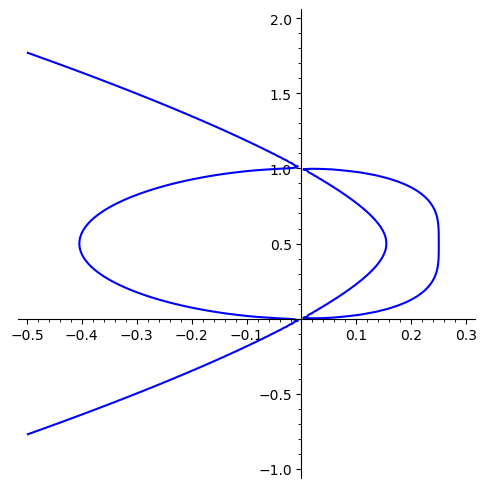

In [14]:
# Plot algebraic curve defined by P = 0
# Note: plots with black background for slides are below
equation = P == 0
p = implicit_plot(equation, (z, -0.5, 0.3), (y, -1, 2), frame=False, axes=True)
p.show(figsize=[5, 5], aspect_ratio='automatic')

In [15]:
# Compute series solutions around the origin -- note all are power series!
compute_Puiseux_solutions(P, z, y, 3)

[1 - 2*z - 2*z^2 + O(z^(5/2)),
 1 - 2*z^2 - 2*z^3 + O(z^(7/2)),
 2*z + 2*z^2 + 6*z^3 + 24*z^4 + O(z^5),
 2*z^2 + 2*z^3 + 8*z^4 + 18*z^5 + O(z^6)]

In [16]:
# Expansion in t = 1 - 4z
var('t')
ser = compute_Puiseux_solutions(P.subs(z=(1-t)/4), t, y, 2)
ser

[1/2 - 1/2*t^(1/4) + O(t^(3/4)),
 1/2 + 1/2*t^(1/4) + O(t^(3/4)),
 1/2 - 0.50000000000000000?*I*t^(1/4) + O(t^(3/4)),
 1/2 + 0.50000000000000000?*I*t^(1/4) + O(t^(3/4))]

### Part 3: D-Finite Functions

In [17]:
# Define the ring of shift operators
from ore_algebra import *
Ind.<n> = PolynomialRing(QQ); Shift.<Sn> = OreAlgebra(Ind)

In [18]:
# Algebraic Simplification
Sn * n
(n + 1)*Sn

(n + 1)*Sn

In [19]:
# Recurrence for central binomial coefficients
rec = (n + 1)*Sn - 4*n - 2 
rec.to_list([1],10)

[1, 2, 6, 20, 70, 252, 924, 3432, 12870, 48620]

In [20]:
[binomial(2*k,k) for k in range(10)]

[1, 2, 6, 20, 70, 252, 924, 3432, 12870, 48620]

In [21]:
# Use recurrence to quickly compute binomial(2000,1000)
rec.to_list([1],1001)[1000]

2048151626989489714335162502980825044396424887981397033820382637671748186202083755828932994182610206201464766319998023692415481798004524792018047549769261578563012896634320647148511523952516512277685886115395462561479073786684641544445336176137700738556738145896300713065104559595144798887462063687185145518285511731662762536637730846829322553890497438594814317550307837964443708100851637248274627914170166198837648408435414308177859470377465651884755146807496946749238030331018187232980096685674585602525499101181135253534658887941966653674904511306110096311906270342502293155911108976733963991149120

In [22]:
# Get list of first 10 central binomial coefficients squared
LST = [binomial(2*k,k)^2 for k in range(10)]
LST

[1, 4, 36, 400, 4900, 63504, 853776, 11778624, 165636900, 2363904400]

In [23]:
# Guess recurrence from list
guess(LST,Shift)

(-n^2 - 2*n - 1)*Sn + 16*n^2 + 16*n + 4

In [24]:
# Code to generated NSEW walks restricted to the first quadrant
@CachedFunction 
def NSEW(i,j,n):
    if i<0 or j<0:               return 0
    elif n==0 and i==0 and j==0: return 1
    elif n==0:                   return 0
    else:                        return NSEW(i-1,j,n-1) + NSEW(i,j-1,n-1) + NSEW(i+1,j,n-1) + NSEW(i,j+1,n-1)
    
def w(n): return add([NSEW(i,j,n) for i in range(n+1) for j in range(n+1)])

In [25]:
# Print first 50 terms in the counting sequence for these walks
print([w(n) for n in range(50)])

[1, 2, 6, 18, 60, 200, 700, 2450, 8820, 31752, 116424, 426888, 1585584, 5889312, 22084920, 82818450, 312869700, 1181952200, 4491418360, 17067389768, 65166397296, 248817153312, 953799087696, 3656229836168, 14062422446800, 54086240180000, 208618354980000, 804670797780000, 3111393751416000, 12030722505475200, 46619049708716400, 180648817621276050, 701342468412012900, 2722858995011344200, 10588896091710783000, 41179040356653045000, 160381525599596070000, 624643836545795220000, 2436110962528601358000, 9500832753861545296200, 37098489800792700680400, 144860769698333402656800, 566273917911666937658400, 2213616224563788938119200, 8661976530901782801336000, 33894690773093932700880000, 132754205527951236411780000, 519953971651142342612805000, 2038219568872477983042195600, 7989820709980113693525406752]


In [26]:
# Guess a recurrence
rec = guess([w(n) for n in range(50)], Shift)
rec

(-n^2 - 7*n - 12)*Sn^2 + (8*n + 20)*Sn + 16*n^2 + 48*n + 32

In [27]:
# Use the recurrence to compute number of walks of length 10,000
rec.to_list([1,2],10001)[10000]

5067085828236310945088253321938525911679165154086044352867378892200677466022013531007656719066587766322749761052521681517942919660794947846874891555315237574965336122112599494547431261655133078510805073712599914941885495825331376078850034241904918848154819595587263307268733036055679461265417104904721129019589545602577660116624723244680035087106985338654864004302387598320644982795666073023467922451609719856617334546622620691280671722301078320043145023852770677009584421101972242625179336695022938602180795912966528052367600179921726705247863220166873318725236689765952059916774587133065591626888967330236280183842693647010525007706948897893190173157896622536061539470237050708936089515406550466670058710409014676092931321735109953993314056765593608265568129917077590516564485815379834802877780600423745349837869681691171313936195142084586572626205199406699264939933720473090422822184491387847568760874783537319873877575321989279643637204401534354679512067552569940834063479148658474179018339394092

In [28]:
# Get "asymptotic basis" for the guessed recurrence
show(rec.generalized_series_solutions(n=3))

[4^n*n^(-1)*(1 - 3/2*n^(-1) + 19/8*n^(-2) + O(n^(-3))),
 (-4)^n*n^(-3)*(1 - 9/2*n^(-1) + 107/8*n^(-2) + O(n^(-3)))]

In [29]:
# Define the differential Weyl algebra
Pols.<z> = PolynomialRing(QQ); Diff.<Dz> = OreAlgebra(Pols)
Dz * z


z*Dz + 1

In [30]:
# Convert recurrence for NSEW walks above to differential operator
rec.to_D(Diff)

(16*z^4 - z^2)*Dz^4 + (192*z^3 + 8*z^2 - 8*z)*Dz^3 + (608*z^2 + 44*z - 12)*Dz^2 + (512*z + 40)*Dz + 64

In [31]:
# Guess annihilating differential operator for walk generating function directly
deq = guess([w(n) for n in range(50)],Diff)
deq

(16*z^4 - z^2)*Dz^3 + (128*z^3 + 8*z^2 - 6*z)*Dz^2 + (224*z^2 + 28*z - 6)*Dz + 64*z + 12

In [32]:
# Local basis of solutions to guessed ODE centred at z = 0
deq.local_basis_expansions(0)

[z^(-2) - 4*z^(-1)*log(z) - 8*log(z) - 16*z*log(z) - 8*z - 48*z^2*log(z) - 28*z^2 - 144*z^3*log(z) - 96*z^3,
 z^(-1),
 1 + 2*z + 6*z^2 + 18*z^3]

In [33]:
# Local basis of solutions to guessed ODE centred at z = 1
deq.local_basis_expansions(1)

[1 - 38/45*(z - 1)^3 + 568/225*(z - 1)^4 - 86132/16875*(z - 1)^5,
 (z - 1) - 41/15*(z - 1)^3 + 541/75*(z - 1)^4 - 76484/5625*(z - 1)^5,
 (z - 1)^2 - 26/9*(z - 1)^3 + 256/45*(z - 1)^4 - 32039/3375*(z - 1)^5]

In [34]:
# Local basis of solutions to guessed ODE centred at z = 1/4
deq.local_basis_expansions(1/4)

[log(z - 1/4) - 6*(z - 1/4)*log(z - 1/4) + 31*(z - 1/4)^2*log(z - 1/4) - 150*(z - 1/4)^3*log(z - 1/4) - 2/3*(z - 1/4)^3 + 2797/4*(z - 1/4)^4*log(z - 1/4) + 55/8*(z - 1/4)^4 - 6363/2*(z - 1/4)^5*log(z - 1/4) - 2869/60*(z - 1/4)^5,
 1 - 14*(z - 1/4)^2 + 108*(z - 1/4)^3 - 1261/2*(z - 1/4)^4 + 3291*(z - 1/4)^5,
 (z - 1/4) - 15/2*(z - 1/4)^2 + 43*(z - 1/4)^3 - 1773/8*(z - 1/4)^4 + 4315/4*(z - 1/4)^5]

In [35]:
# Compute numerical transition matrix going from basis at z = 0 to basis at z = 1/4
# Then express the GF of interest in terms of the basis at z = 1/4
ini = vector([0,0,1])
bas = deq.numerical_transition_matrix([0,1/4],1e-5) * ini
bas

([-1.27324 +/- 1.82e-6] + [+/- 1.87e-12]*I, [-2.39070 +/- 6.34e-6] + [4.00000 +/- 3.82e-6]*I, [12.8907 +/- 5.22e-5] + [-24.0000 +/- 3.06e-5]*I)

In [36]:
# Series expansion of the GF of interest around z=1/4
loc = deq.local_basis_expansions(1/4,2)
add([a*b for [a,b] in zip(bas,loc)])

([-1.27324+/-1.82e-6]+[+/-1.87e-12]*I)*log(z - 1/4) + ([7.6394+/-4.06e-5]+[+/-1.13e-11]*I)*(z - 1/4)*log(z - 1/4) + ([-2.39070+/-6.34e-6]+[4.00000+/-3.82e-6]*I)*1 + ([12.8907+/-5.22e-5]+[-24.0000+/-3.06e-5]*I)*(z - 1/4)

In [37]:
# Go from guessed ODE to asymptotics directly -- and with bounded 
# error -- using the work of Dong, Melczer, and Mezzarobba
from ore_algebra.analytic.singularity_analysis import *
bound_coefficients(deq, [1, 2, 6], order=2, prec=20)

1.00000*4^n*(([1.2732 +/- 4.39e-5] + [+/- 2.04e-18]*I)*n^(-1) + ([-1.9099 +/- 5.60e-5] + [+/- 3.06e-18]*I)*n^(-2) + B([1503.38 +/- 3.05e-3]*n^(-3)*log(n), n >= 7))

In [38]:
# Putting everything together to go from naive function computing 
# series terms to guessed asymptotics in a few lines
@CachedFunction 
def NSEW(i,j,n):
    if i<0 or j<0:               return 0
    elif n==0 and i==0 and j==0: return 1
    elif n==0:                   return 0
    else:                        return NSEW(i-1,j,n-1) + NSEW(i,j-1,n-1) + NSEW(i+1,j,n-1) + NSEW(i,j+1,n-1)
def w(n): return add([NSEW(i,j,n) for i in range(n+1) for j in range(n+1)])

from ore_algebra import *
from ore_algebra.analytic.singularity_analysis import *
Pols.<z> = PolynomialRing(QQ); Diff.<Dz> = OreAlgebra(Pols);

deq = guess([w(n) for n in range(50)],Diff)
bound_coefficients(deq, [w(n) for n in range(3)])

1.000000000000000*4^n*(([1.27323954473516 +/- 3.09e-15] + [+/- 1.21e-30]*I)*n^(-1) + ([-1.90985931710274 +/- 4.63e-15] + [+/- 1.81e-30]*I)*n^(-2) + ([3.02394391874601 +/- 6.05e-15] + [+/- 6.46e-30]*I)*n^(-3) + B([3432.030228663511 +/- 9.35e-13]*n^(-4)*log(n), n >= 9) + [0.318309886183791 +/- 7.53e-16]*(e^(I*arg(-1)))^n*n^(-3))

In [39]:
# Bounded asymptotic expansion for sequence proving uniqueness of the genus one Canham model
seqini = [72, 1932, 31248, 790101/2, 17208645/4, 338898609/8, 1551478257/4]
deq = (8388593*z^2*(3*z^4 - 164*z^3 + 370*z^2 - 164*z + 3)*(z + 1)^2*(z^2 - 6*z + 1)^2*(z - 1)^3*Dz^3 \
       + 8388593*z*(z + 1)*(z^2 - 6*z + 1)*(66*z^8 - 3943*z^7 + 18981*z^6 - 16759*z^5 - 30383*z^4 + 47123*z^3 - 17577*z^2 + 971*z - 15)*(z - 1)^2*Dz^2 \
       + 16777186*(z - 1)*(210*z^12 - 13761*z^11 + 101088*z^10 - 178437*z^9 - 248334*z^8 + 930590*z^7 - 446064*z^6 - 694834*z^5 + 794998*z^4 - 267421*z^3 + 24144*z^2 - 649*z + 6)*Dz \
       + 6341776308*z^12 - 427012938072*z^11 + 2435594423178*z^10 - 2400915979716*z^9 - 10724094731502*z^8 + 26272536406048*z^7 - 8496738740956*z^6 - 30570113263064*z^5 + 39394376229112*z^4 - 19173572139496*z^3 + 3825886272626*z^2 - 170758199108*z + 2701126946)
bound_coefficients(deq, seqini, order=5, prec=20, n0=50)

1.00000*5.828427124746190?^n*(([8.072 +/- 1.77e-4] + [+/- 1.57e-12]*I)*n^3*log(n) + ([1.371 +/- 5.79e-4] + [+/- 1.08e-4]*I)*n^3 + ([50.509 +/- 8.16e-4] + [+/- 9.77e-12]*I)*n^2*log(n) + ([29.70 +/- 2.92e-3] + [+/- 6.71e-4]*I)*n^2 + ([106.36 +/- 2.08e-3] + [+/- 2.06e-11]*I)*n*log(n) + ([118.76 +/- 5.85e-3] + [+/- 1.42e-3]*I)*n + ([72.85 +/- 4.56e-3] + [+/- 1.41e-11]*I)*log(n) + [154.7 +/- 0.0133] + [+/- 9.55e-4]*I + ([-0.28378 +/- 3.33e-6] + [+/- 5.49e-14]*I)*n^(-1)*log(n) + ([35.5 +/- 0.0224] + [+/- 3.41e-6]*I)*n^(-1) + B([3056.71 +/- 2.97e-3]*n^(-2)*log(n)^2, n >= 50))

In [40]:
# Bounded asymptotics for N-SE-SW walks in N^2
# Because of connection problem, can't prove the coefficients are zero
ini = [1,1,2,3,8,15,39]
deq = (196608*z^16 - 4096*z^15 - 106496*z^14 + 90112*z^13 + 4096*z^12 + 16192*z^11 + 3776*z^10 - 4736*z^9 - 560*z^8 - 124*z^7 - 33*z^6 + 52*z^5 + 7*z^4 - 2*z^3)*Dz^4 + (3145728*z^15 - 462848*z^14 - 1073152*z^13 + 1252352*z^12 + 192512*z^11 + 370112*z^10 + 76800*z^9 - 58176*z^8 - 11152*z^7 - 2468*z^6 - 968*z^5 + 518*z^4 + 90*z^3 - 22*z^2)*Dz^3 + (14155776*z^14 - 3870720*z^13 - 2199552*z^12 + 4733952*z^11 + 1582080*z^10 + 2059392*z^9 + 525696*z^8 - 164256*z^7 - 47904*z^6 - 9648*z^5 - 5508*z^4 + 1236*z^3 + 306*z^2 - 60*z)*Dz^2 + (18874368*z^13 - 7544832*z^12 + 294912*z^11 + 5081088*z^10 + 3201024*z^9 + 3148416*z^8 + 1068864*z^7 - 68832*z^6 - 41136*z^5 - 5520*z^4 - 7584*z^3 + 648*z^2 + 276*z - 36)*Dz + 4718592*z^12 - 2482176*z^11 + 811008*z^10 + 964608*z^9 + 1075200*z^8 + 880128*z^7 + 387648*z^6 + 31296*z^5 + 6864*z^4 + 3024*z^3 - 1320*z^2 + 72*z + 36
bound_coefficients(deq, ini, prec=20)

1.00000*3^n*(([+/- 1.56e-12] + [+/- 1.56e-12]*I)*n^(-1/2) + ([+/- 3.21e-12] + [+/- 3.21e-12]*I)*n^(-3/2) + ([+/- 8.71e-12] + [+/- 8.71e-12]*I)*n^(-5/2) + B([2.18961e+7 +/- 68.1]*n^(-7/2), n >= 10))

In [41]:
# Heuristically verify D-algebraic equation for integer partitions 
var('q')
P = mul([1/(1-q^k) for k in range(1,25)]).series(q,25).truncate()

# Should be O(q^20)
(q^2*P^3*diff(P, q, 4)
    + 20*q^2*P^2*diff(P, q)*diff(P, q, 3)
    - 39*q^2*P^2*diff(P, q, 2)^2
    + 12*q^2*P*diff(P, q)^2*diff(P, q, 2)
    + 6*q^2*diff(P, q)^4
    + 5*q*P^3*diff(P, q, 3)
    - 15*q*P^2*diff(P, q)*diff(P, q, 2)
    + 10*q*P*diff(P, q)^3
    + 4*P^3*diff(P, q, 2)
    - 16*P^2*diff(P, q)^2
).series(q,20)

Order(q^20)

### Stylized Plots for Slides

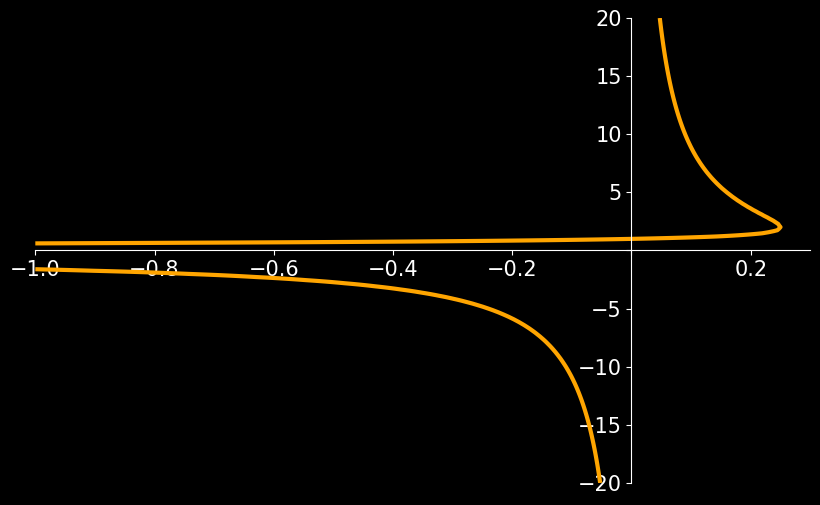

In [42]:
# Catalan GF
import matplotlib.pyplot as plt
plt.style.use('dark_background')

var('z y')
equation = z*y^2 - y + 1 == 0
p = implicit_plot(equation, (z, -1, 0.3), (y, -20, 20), 
                  color='orange', 
                  frame=True, 
                  axes=False, 
                  aspect_ratio='automatic',
                  linewidth=3)

fig = p.matplotlib(figsize=[10, 10])
ax = fig.axes[0]

ax.set_xlim(-1, 0.3)
ax.set_ylim(-20, 20)
ax.set_box_aspect(0.6)

# Move the lines to the center
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(colors='white', labelsize=15)

# Annoying hack to display the figure in Jupyter notebook
import io
from IPython.display import display, Image
buf = io.BytesIO()
fig.savefig(buf, format='png', facecolor='black', bbox_inches='tight')
buf.seek(0)
display(Image(buf.getvalue()))

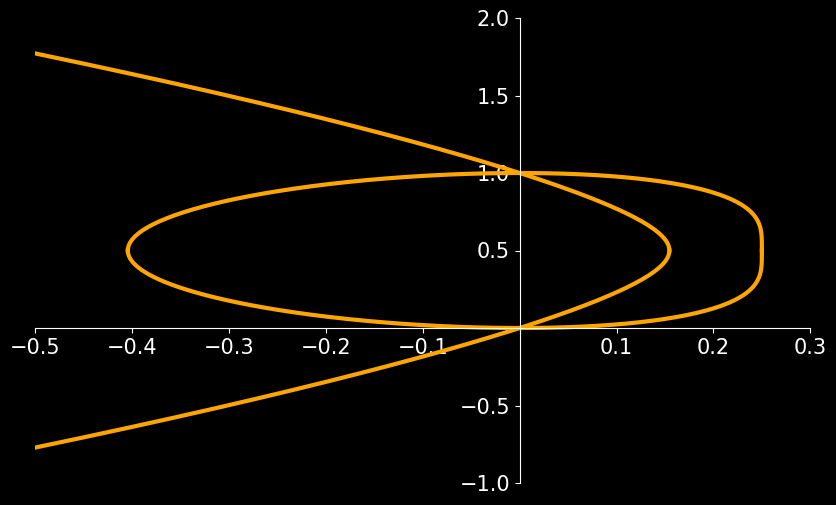

In [43]:
# Bicoloured Supertrees
import matplotlib.pyplot as plt
plt.style.use('dark_background')

var('z y')
P = y^4 - 2*y^3 + (1+2*z)*y^2 - 2*y*z + 4*z^3
[r1,r2,r3,r4] = [k.rhs() for k in P.solve(y)]
p1 = plot(r1, (z, -0.5, 1/8*sqrt(5) - 1/8), 
                  color='orange', 
                  frame=True, 
                  axes=False, 
                  aspect_ratio='automatic',
                  thickness=3)
p2 = plot(r2, (z, -0.5, 1/8*sqrt(5) - 1/8), 
                  color='orange', 
                  frame=True, 
                  axes=False, 
                  aspect_ratio='automatic',
                  thickness=3)
p3 = plot(r3, (z, -1/8*sqrt(5) - 1/8, 0.25), 
                  color='orange', 
                  frame=True, 
                  axes=False, 
                  aspect_ratio='automatic',
                  thickness=3)
p4 = plot(r4, (z, -1/8*sqrt(5) - 1/8, 0.25), 
                  color='orange', 
                  frame=True, 
                  axes=False, 
                  aspect_ratio='automatic',
                  thickness=3)

fig = (p1+p2+p3+p4).matplotlib(figsize=[10, 10])
ax = fig.axes[0]

ax.set_xlim(-0.5, 0.3)
ax.set_ylim(-1, 2)
ax.set_box_aspect(0.6)

# Move the lines to the center
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(colors='white', labelsize=15)

# Annoying hack to display the figure in Jupyter notebook
import io
from IPython.display import display, Image
buf = io.BytesIO()
fig.savefig(buf, format='png', facecolor='black', bbox_inches='tight')
buf.seek(0)
display(Image(buf.getvalue()))

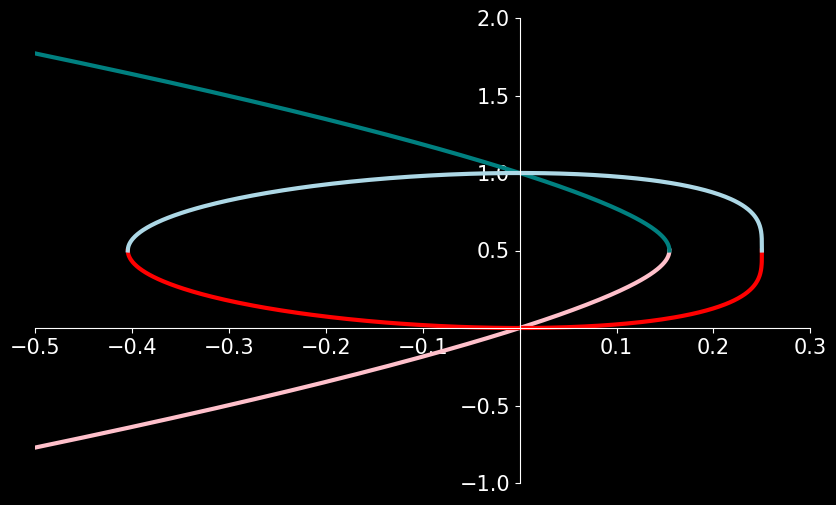

In [44]:
# Bicoloured Supertrees with distinct branches coloured
import matplotlib.pyplot as plt
plt.style.use('dark_background')

var('z y')
p1 = plot(r1, (z, -0.5, 1/8*sqrt(5) - 1/8), 
                  color='pink', 
                  frame=True, 
                  axes=False, 
                  aspect_ratio='automatic',
                  thickness=3)
p2 = plot(r2, (z, -0.5, 1/8*sqrt(5) - 1/8), 
                  color='teal', 
                  frame=True, 
                  axes=False, 
                  aspect_ratio='automatic',
                  thickness=3)
p3 = plot(r3, (z, -1/8*sqrt(5) - 1/8, 0.25), 
                  color='red', 
                  frame=True, 
                  axes=False, 
                  aspect_ratio='automatic',
                  thickness=3)
p4 = plot(r4, (z, -1/8*sqrt(5) - 1/8, 0.25), 
                  color='lightblue', 
                  frame=True, 
                  axes=False, 
                  aspect_ratio='automatic',
                  thickness=3)

fig = (p1+p2+p3+p4).matplotlib(figsize=[10, 10])
ax = fig.axes[0]

ax.set_xlim(-0.5, 0.3)
ax.set_ylim(-1, 2)
ax.set_box_aspect(0.6)

# Move the lines to the center
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(colors='white', labelsize=15)

# Annoying hack to display the figure in Jupyter notebook
import io
from IPython.display import display, Image
buf = io.BytesIO()
fig.savefig(buf, format='png', facecolor='black', bbox_inches='tight')
buf.seek(0)
display(Image(buf.getvalue()))